# Trabalho Final ML2 - Fine-grained classification on SLICE-3D dataset
**Bianca Zavadisk de Abreu**

## Configuração de ambiente e reprodutibilidade

In [1]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


In [ ]:
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torchvision
from torchvision import transforms

import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "BZA_19_05_2026"
output_dir = Path("finalProject_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu128
Versão do Torchvision: 0.26.0+cu128
Diretório de saída: finalProject_outputs/BZA_19_05_2026


## Carregamento do dataset reduzido ISIC2018

Em primeiro momento buscamos definir a aqruitetura e testar diferentes hiperparâmetros. Então, considerando a extensão do dataset SLICE-3D (~400k), primeiro importamos um dataset reduzido (~10k) no mesmo contexto de imagens e classificação.

In [ ]:
from isic2018_dataset import download_isic2018, get_dataloaders

IMAGE_SIZE = 224
BATCH_SIZE = 32

download_isic2018(root="./data/isic2018")


  Split: TRAIN
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_Input.zip …


  Extraindo train_images.zip → data/isic2018/_cache/train_images_extracted …
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_GroundTruth.zip …


  Extraindo train_gt.zip → data/isic2018/_cache/train_gt_extracted …

  Split: VAL
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Validation_Input.zip …


  Extraindo val_images.zip → data/isic2018/_cache/val_images_extracted …
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Validation_GroundTruth.zip …


  Extraindo val_gt.zip → data/isic2018/_cache/val_gt_extracted …

  Split: TEST
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Test_Input.zip …


  Extraindo test_images.zip → data/isic2018/_cache/test_images_extracted …
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Test_GroundTruth.zip …


  Extraindo test_gt.zip → data/isic2018/_cache/test_gt_extracted …

✓ Download concluído. Dados em: /mnt/storage_C1/bianca_zavadisk/ml2/fine-grained-ml2/data/isic2018


In [17]:

train_loader, val_loader, test_loader = get_dataloaders(
    root="./data/isic2018",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    train_transform=transforms.ToTensor(),
    val_transform=transforms.ToTensor(),
    test_transform=transforms.ToTensor()
)

In [18]:
print(f'Conjunto de treino: {len(train_loader.dataset)} imagens')
print(f'Conjunto de validação: {len(val_loader.dataset)} imagens')
print(f'Conjunto de teste: {len(test_loader.dataset)} imagens')

Conjunto de treino: 10015 imagens
Conjunto de validação: 193 imagens
Conjunto de teste: 1512 imagens


In [19]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, ConcatDataset

dataset = ConcatDataset([train_loader.dataset, val_loader.dataset])

labels = []
for ds in dataset.datasets:
    if hasattr(ds, "targets"):
        labels.extend(list(ds.targets))
    elif hasattr(ds, "labels"):
        labels.extend(list(ds.labels))
    else:
        # fallback (pode ser caro pois itera o dataset)
        labels.extend([lbl for _, lbl in ds])

# Stratified split no dataset concatenado
train_idx, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.15,
    stratify=labels,
    random_state=seed,
)

train_subset = Subset(dataset, train_idx)
val_subset = Subset(dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [20]:
print(f'Conjunto de treino: {len(train_loader.dataset)} imagens')
print(f'Conjunto de validação: {len(val_loader.dataset)} imagens')
print(f'Conjunto de teste: {len(test_loader.dataset)} imagens')

Conjunto de treino: 8676 imagens
Conjunto de validação: 1532 imagens
Conjunto de teste: 1512 imagens


In [21]:
images, labels = next(iter(train_loader))

print("Shape de image (após resize):", images.shape)
print("Shape dos labels:", labels.shape)
print("dtype de images:", images.dtype)
print("dtype de labels:", labels.dtype)
print("Primeiros labels:", labels[:10])

Shape de image (após resize): torch.Size([32, 3, 450, 600])
Shape dos labels: torch.Size([32])
dtype de images: torch.float32
dtype de labels: torch.int64
Primeiros labels: tensor([1, 1, 0, 1, 1, 1, 4, 1, 6, 1])


## Análise exploratória

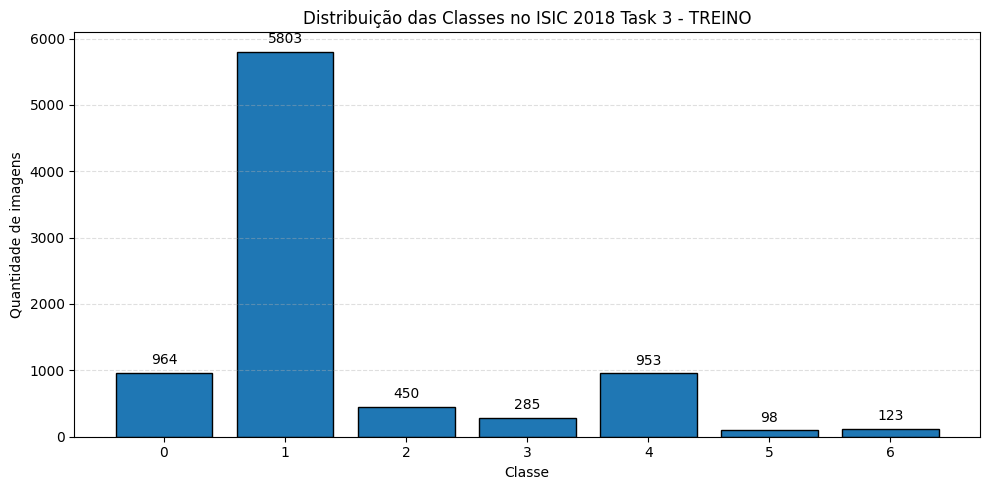

In [ ]:
# Análise das classes
from collections import Counter

#Extrai todas as labels
all_labels = [label for _, label in train_loader.dataset]
counts = Counter(all_labels)

plt.figure(figsize=(10, 5))
bars = plt.bar(x=list(counts.keys()), height=list(counts.values()), color="tab:blue", edgecolor="black")
plt.title("Distribuição das Classes no ISIC 2018 Task 3 - TREINO")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

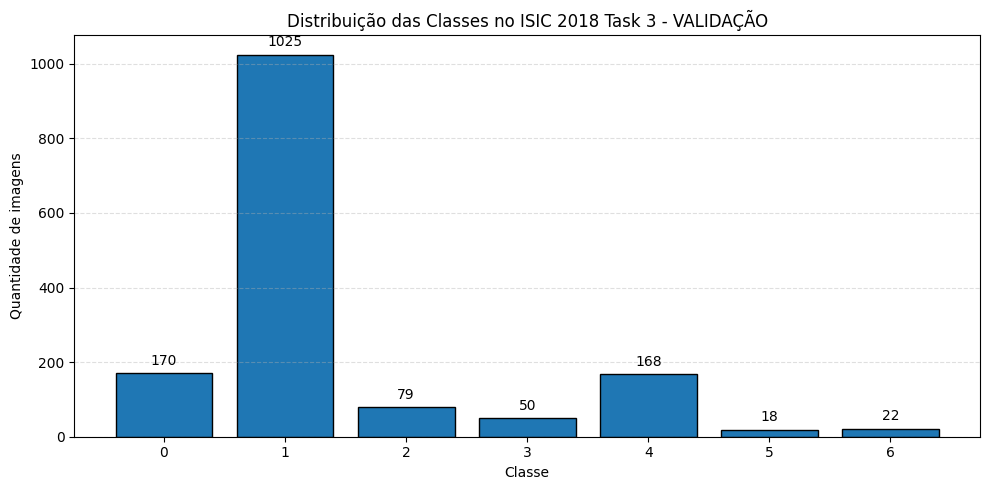

In [23]:
all_labels = [label for _, label in val_loader.dataset]
counts = Counter(all_labels)

plt.figure(figsize=(10, 5))
bars = plt.bar(x=list(counts.keys()), height=list(counts.values()), color="tab:blue", edgecolor="black")
plt.title("Distribuição das Classes no ISIC 2018 Task 3 - VALIDAÇÃO")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

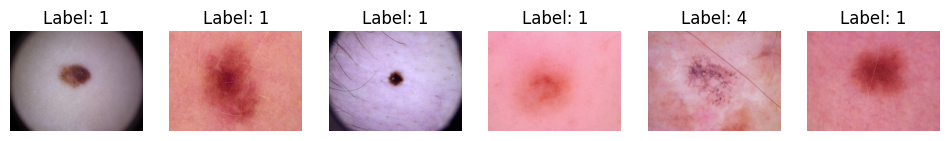

In [26]:
# Exibe algumas imagens
dataiter = iter(train_loader)

# função next() para pegar o primeiro batch
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))

for i in range(6):
    img = images[i].permute(1, 2, 0) # Transforma de (C, H, W) para (H, W, C)

    axes[i].imshow(img)
    axes[i].set_title(f'Label: {labels[i].item()}')
    axes[i].axis('off')

plt.show()

Pelo histograma observamos um encoding de 7 classes de diagnóstico. Em uma análise dos metadados do dataset, verificamos que os diagnósticos são os descritos na tabela abaixo.

Ainda, podemos agrupar tais diagnósticos em um nível mais simples, buscando classificar apenas entre benigno e maligno. Para isso, consideramos lesões pré-cancerosas (AKIEC) também como malignas, o que é comum em datasets do mesmo tipo.

|Encoding | Sigla | Nome Completo (Inglês) | Tradução (Português) | Maligno / Benigno | Descrição e Classificação Clínica |
| --- | --- | --- | --- | --- | --- |
|0| **MEL** | Melanoma | Melanoma | **Maligno** | O câncer de pele mais grave e agressivo. Desenvolve-se nas células que produzem pigmento (melanócitos) e possui alto risco de metástase. |
|1| **NV** | Melanocytic Nevus | Nevo Melanocítico | **Benigno** | Popularmente conhecido como "pinta" ou "sinal". É uma proliferação comum e totalmente benigna de melanócitos. |
|2| **BCC** | Basal Cell Carcinoma | Carcinoma Basocelular | **Maligno** | O tipo mais comum e menos agressivo de câncer de pele. Tem crescimento lento e raramente se espalha para outros órgãos. |
|3| **AKIEC** | Actinic Keratoses and Intraepithelial Carcinoma | Queratose Actínica e Carcinoma Intraepitelial | **Maligno** | Engloba lesões pré-cancerosas e cânceres em estágio inicial *in situ*. Geralmente causadas por exposição prolongada ao sol. |
|4| **BKL** | Benign Keratosis-like Lesions | Lesões Benignas semelhantes à Queratose | **Benigno** | Grupo de lesões benignas sem risco de câncer, incluindo queratoses seborreicas (como as "manchas senis"). |
|5| **DF** | Dermatofibroma | Dermatofibroma | **Benigno** | Lesão fibrosa benigna, geralmente apresentando-se como um nódulo firme sob a pele, de crescimento lento (muito comum nas pernas). |
|6| **VASC** | Vascular Lesions | Lesões Vasculares | **Benigno** | Conjunto de lesões benignas formadas por vasos sanguíneos anormais, como hemangiomas e os famosos "sinais de rubi". |

Abaixo vemos algumas imagens de cada classe.

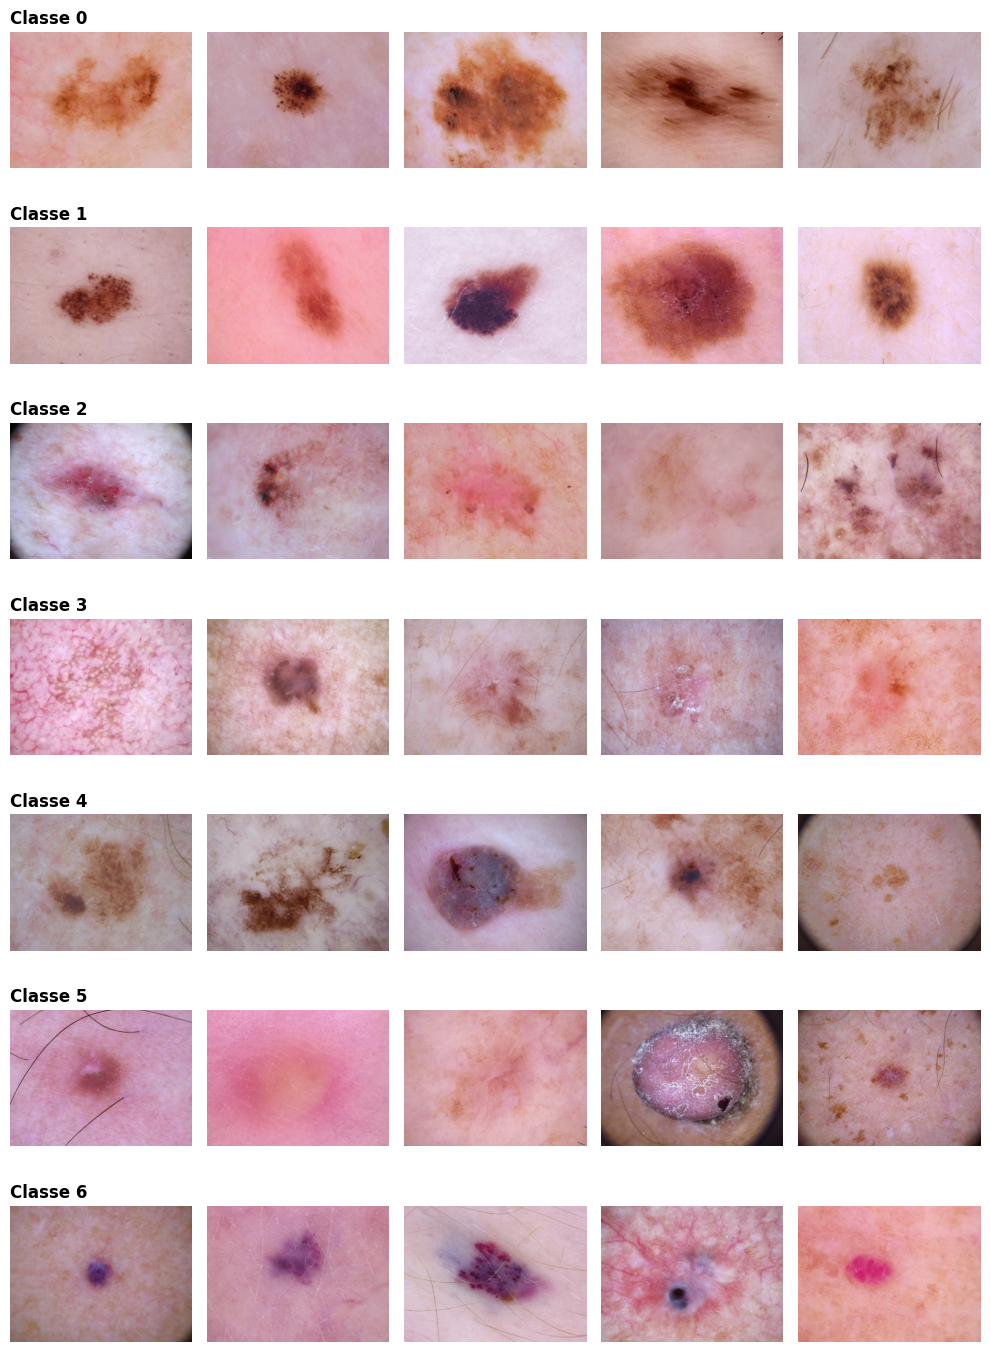

In [27]:
def exibir_imagens_por_classe(loader, num_samples=3):
    """Exibe um número específico de imagens para cada classe presente no DataLoader.

    :param loader: PyTorch DataLoader
    :param num_samples: Quantidade de imagens a exibir por classe
    """
    # Tenta pegar os nomes das classes do dataset, se existirem
    class_names = (
        loader.dataset.classes if hasattr(loader.dataset, "classes") else None
    )

    imagens_por_classe = {}

    # 1. Coleta as imagens necessárias
    for num_batch, (images, labels) in enumerate(loader):
        for img, lbl in zip(images, labels):
            classe = lbl.item() if isinstance(lbl, torch.Tensor) else lbl

            if classe not in imagens_por_classe:
                imagens_por_classe[classe] = []

            # Adiciona a imagem se ainda não atingiu o limite para essa classe
            if len(imagens_por_classe[classe]) < num_samples:
                imagens_por_classe[classe].append(img)

        # Verifica se já temos amostras suficientes de TODAS as classes coletadas até agora
        # (Isso evita rodar o loader inteiro se o dataset for gigante)
        if class_names and len(imagens_por_classe) == len(class_names):
            if all(
                len(imgs) == num_samples for imgs in imagens_por_classe.values()
            ):
                break

    classes_ordenadas = sorted(imagens_por_classe.keys())
    num_classes = len(classes_ordenadas)

    fig, axes = plt.subplots(
        num_classes, num_samples, figsize=(num_samples * 2, num_classes * 2)
    )

    # Ajuste para o caso de termos apenas 1 classe ou 1 amostra (evita quebra do numpy)
    if num_classes == 1 and num_samples == 1:
        axes = np.array([[axes]])
    elif num_classes == 1:
        axes = np.expand_dims(axes, axis=0)
    elif num_samples == 1:
        axes = np.expand_dims(axes, axis=1)

    for idx_classe, classe in enumerate(classes_ordenadas):
        imagens = imagens_por_classe[classe]

        for idx_img in range(num_samples):
            ax = axes[idx_classe, idx_img]

            if idx_img >= len(imagens):
                ax.axis("off")
                continue

            img = imagens[idx_img]

            if isinstance(img, torch.Tensor):
                img = img.permute(1, 2, 0).cpu().numpy()    # (C, H, W) -> (H, W, C)

            if img.shape[-1] == 1:
                ax.imshow(img.squeeze(), cmap="gray")
            else:
                ax.imshow(img)

            ax.axis("off")

            if idx_img == 0:
                nome_classe = (
                    class_names[classe] if class_names else f"Classe {classe}"
                )
                ax.set_title(
                    nome_classe, loc="left", fontsize=12, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

exibir_imagens_por_classe(train_loader, num_samples=5)

### Agrupamento binário: maligno/benigno

In [33]:
benign = [1, 4, 5, 6]
malignant = [0, 2, 3]

# Cria loaders para a classificação binária

class BinaryDataset(torch.utils.data.Dataset):
    """Wrap any dataset to map multi-class labels into binary (0=benign, 1=malignant)."""
    def __init__(self, base_dataset, benign_classes, malignant_classes):
        self.base = base_dataset
        self.label_map = {}
        for c in benign_classes:
            self.label_map[int(c)] = 0
        for c in malignant_classes:
            self.label_map[int(c)] = 1

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, lbl = self.base[idx]
        # normalize label type
        lbl_val = int(lbl.item()) if isinstance(lbl, torch.Tensor) else int(lbl)
        if lbl_val not in self.label_map:
            raise KeyError(f"Label {lbl_val} not in benign/malignant mapping.")
        return img, self.label_map[lbl_val]

# Cria datasets binários mantendo exatamente as mesmas partições (subsets) usadas antes
train_binary_ds = BinaryDataset(train_loader.dataset, benign, malignant)
val_binary_ds = BinaryDataset(val_loader.dataset, benign, malignant)
test_binary_ds = BinaryDataset(test_loader.dataset, benign, malignant)

# Cria DataLoaders para classificação binária
train_binary_loader = DataLoader(train_binary_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_binary_loader = DataLoader(val_binary_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_binary_loader = DataLoader(test_binary_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [32]:
# Informações rápidas
from collections import Counter
def count_labels(dl):
    cnt = Counter()
    for _, lbls in dl:
        for l in lbls:
            cnt[int(l.item()) if isinstance(l, torch.Tensor) else int(l)] += 1
    return cnt

print("Contagem labels (treino) ->", count_labels(train_binary_loader))
print("Contagem labels (val)   ->", count_labels(val_binary_loader))
print("Contagem labels (teste) ->", count_labels(test_binary_loader))

Contagem labels (treino) -> Counter({0: 6977, 1: 1699})
Contagem labels (val)   -> Counter({0: 1233, 1: 299})
Contagem labels (teste) -> Counter({0: 1205, 1: 307})


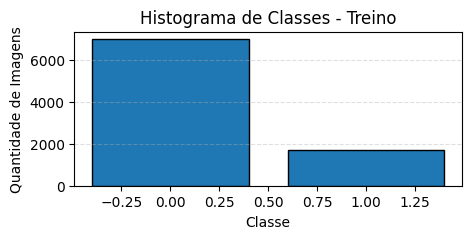

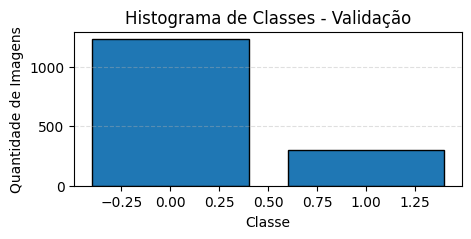

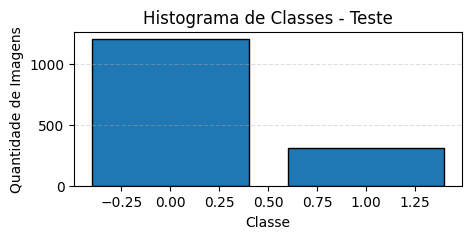

In [34]:
# histogramas
def plot_histogram(loader, title="Histograma de Classes"):
    """Plota um histograma da distribuição de classes em um DataLoader."""
    counts = count_labels(loader)
    plt.figure(figsize=(5, 2))
    plt.bar(x = list(counts.keys()), height=list(counts.values()), color="tab:blue", edgecolor="black")
    plt.title(title)
    plt.xlabel("Classe")
    plt.ylabel("Quantidade de Imagens")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()

plot_histogram(train_binary_loader, title="Histograma de Classes - Treino")
plot_histogram(val_binary_loader, title="Histograma de Classes - Validação")
plot_histogram(test_binary_loader, title="Histograma de Classes - Teste")

### Lidando com dados não balanceados

Podemos explorar algumas soluções para lidar com dados desbalanceados entre as classes. Nessa seção abordaremosas técnicas:
- Ajustar os pesos das classes na loss
- Usar `WeightedRandomSampler`

#### Peso das classes na Loss

In [ ]:
benign_qtd = count_labels(train_binary_loader)[0]
malignant_qtd = count_labels(train_binary_loader)[1]

proportion = benign_qtd / malignant_qtd
bng_weight = torch.tensor([proportion])
criterion = nn.BCEWithLogitsLoss(pos_weight=bng_weight)

## Modelos para transfer learning

Conforme especificado na proposta do projeto, faremos transfer learning usando três arquiteturas:
- ResNet
- EfficientNet
- ViT

buscando explorar tanto aqruiteturas de CNN quando Transformers para a tarefa proposta.

In [35]:
import torch
import torchvision.models as models

# --- 1. RESNET (Exemplo: ResNet50) ---
# O 'DEFAULT' sempre baixa os melhores pesos disponíveis para essa arquitetura
resnet_weights = models.ResNet50_Weights.DEFAULT
model_resnet = models.resnet50(weights=resnet_weights)

# --- 2. EFFICIENTNET (Exemplo: EfficientNet-B0) ---
efficientnet_weights = models.EfficientNet_B0_Weights.DEFAULT
model_efficientnet = models.efficientnet_b0(weights=efficientnet_weights)

# --- 3. VISION TRANSFORMER (Exemplo: ViT-B/16) ---
vit_weights = models.ViT_B_16_Weights.DEFAULT
model_vit = models.vit_b_16(weights=vit_weights)

# --- Configuração para Inferência ---
# Sempre mude para o modo de avaliação (.eval()) se for apenas testar/usar o modelo.
# Isso desativa camadas como Dropout e Batch Normalization.
model_resnet.eval()
model_efficientnet.eval()
model_vit.eval()

print("Todos os modelos foram carregados com sucesso!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/al.bianca.abreu/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 86.0MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/al.bianca.abreu/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 82.8MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/al.bianca.abreu/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 84.0MB/s] 


Todos os modelos foram carregados com sucesso!


In [38]:
transforms_resnet = resnet_weights.transforms()
transforms_efficientnet = efficientnet_weights.transforms()
transforms_vit = vit_weights.transforms()

print("Transformações ResNet:", transforms_resnet)
print("Transformações EfficientNet:", transforms_efficientnet)
print("Transformações ViT:", transforms_vit)

Transformações ResNet: ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
Transformações EfficientNet: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
Transformações ViT: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [37]:
num_classes = 2
model_resnet.fc = torch.nn.Linear(model_resnet.fc.in_features, num_classes)
model_efficientnet.classifier[1] = torch.nn.Linear(model_efficientnet.classifier[1].in_features, num_classes)
model_vit.heads[0] = torch.nn.Linear(model_vit.heads[0].in_features, num_classes)